In [1]:
!pip install sentence-transformers seaborn matplotlib pandas numpy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util

In [3]:
sentences = [
    # Cricket (4 sentences) — indices 0–3
    "The batsman hit a magnificent century in the final over.",
    "India won the match by taking two wickets in the last ball.",
    "The spinner bowled a perfect googly to dismiss the opener.",
    "The fielder took a stunning catch near the boundary rope.",

    # Cooking (3 sentences) — indices 4–6
    "Simmer the onions in butter until they turn golden brown.",
    "Add a pinch of salt and freshly ground pepper to the sauce.",
    "Preheat the oven to 180 degrees before placing the cake inside.",

    # Cybersecurity (3 sentences) — indices 7–9
    "The hacker exploited a SQL injection vulnerability in the login page.",
    "Always enable two-factor authentication to protect your accounts.",
    "Ransomware encrypted all the files and demanded a Bitcoin payment.",
]

# Short labels for heatmap axes
labels = [
    "Cricket 1", "Cricket 2", "Cricket 3", "Cricket 4",
    "Cooking 1", "Cooking 2", "Cooking 3",
    "Cyber 1",   "Cyber 2",   "Cyber 3",
]

In [4]:
print("Loading model...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Generating embeddings...")
embeddings = model.encode(sentences, convert_to_tensor=True)

print(f"Embedding shape: {embeddings.shape}")  # Expected: (10, 384)

Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings...
Embedding shape: torch.Size([10, 384])


In [5]:
cosine_sim_matrix = util.cos_sim(embeddings, embeddings).numpy()

df_sim = pd.DataFrame(cosine_sim_matrix, index=labels, columns=labels)

print("Cosine Similarity Matrix:")
print(df_sim.round(3))

Cosine Similarity Matrix:
           Cricket 1  Cricket 2  Cricket 3  Cricket 4  Cooking 1  Cooking 2  \
Cricket 1      1.000      0.567      0.438      0.399      0.048      0.017   
Cricket 2      0.567      1.000      0.406      0.281      0.081      0.044   
Cricket 3      0.438      0.406      1.000      0.340      0.170      0.104   
Cricket 4      0.399      0.281      0.340      1.000      0.023      0.077   
Cooking 1      0.048      0.081      0.170      0.023      1.000      0.365   
Cooking 2      0.017      0.044      0.104      0.077      0.365      1.000   
Cooking 3      0.049      0.047      0.053      0.002      0.366      0.195   
Cyber 1        0.043      0.051      0.167      0.104      0.049      0.062   
Cyber 2       -0.041     -0.042     -0.041     -0.082     -0.018     -0.008   
Cyber 3        0.065      0.146      0.030      0.000      0.072     -0.011   

           Cooking 3  Cyber 1  Cyber 2  Cyber 3  
Cricket 1      0.049    0.043   -0.041    0.065  
Cric

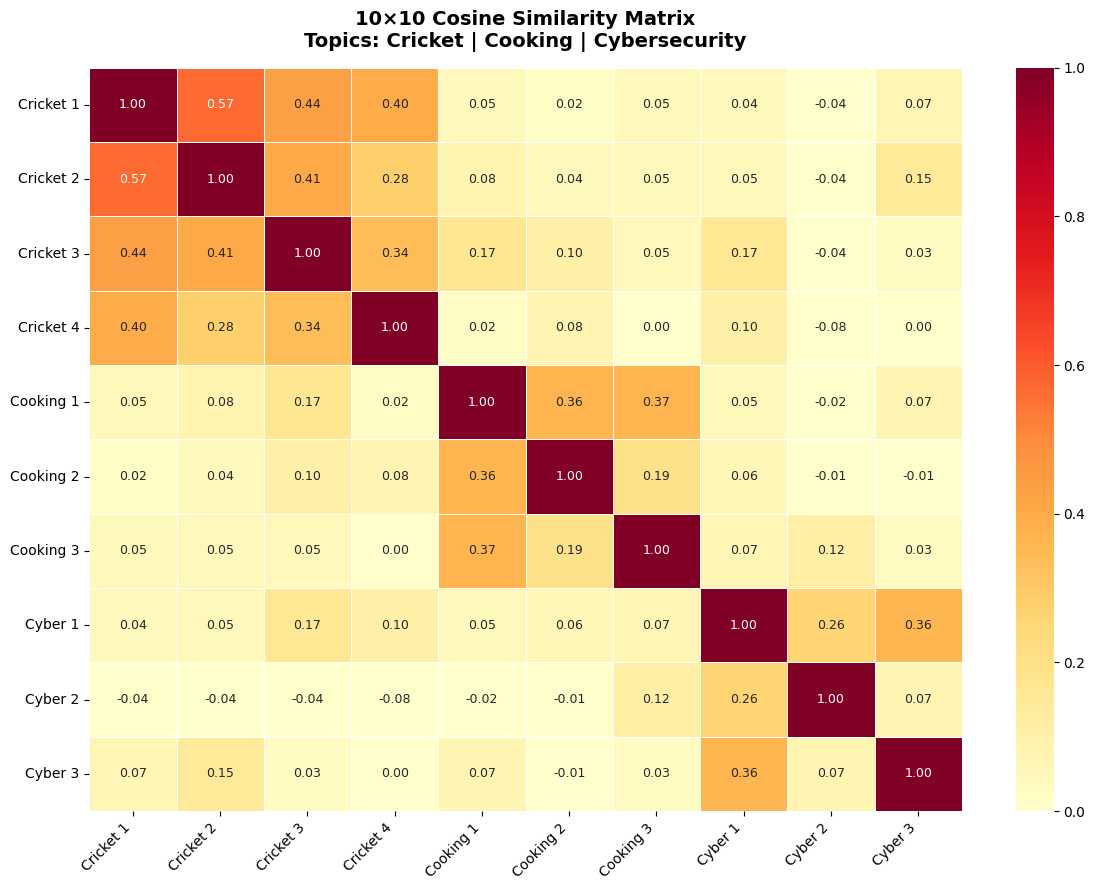

Heatmap saved as similarity_heatmap.png


In [6]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    df_sim,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    vmax=1,
    annot_kws={"size": 9},
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "10×10 Cosine Similarity Matrix\nTopics: Cricket | Cooking | Cybersecurity",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved as similarity_heatmap.png")

In [8]:
query = "The bowler took three wickets in one over"

print(f"Query: \"{query}\"\n")

query_embedding = model.encode(query, convert_to_tensor=True)

similarity_scores = util.cos_sim(query_embedding, embeddings)[0].numpy()

top2_indices = np.argsort(similarity_scores)[::-1][:2]

print("Top 2 Most Similar Sentences:")
print("=" * 55)
for rank, idx in enumerate(top2_indices, start=1):
    print(f"Rank {rank}:")
    print(f"  Sentence : {sentences[idx]}")
    print(f"  Topic    : {labels[idx]}")
    print(f"  Score    : {similarity_scores[idx]:.4f}")
    print()

Query: "The bowler took three wickets in one over"

Top 2 Most Similar Sentences:
Rank 1:
  Sentence : India won the match by taking two wickets in the last ball.
  Topic    : Cricket 2
  Score    : 0.7079

Rank 2:
  Sentence : The batsman hit a magnificent century in the final over.
  Topic    : Cricket 1
  Score    : 0.5936

